This project simulates and visualizes the collision of two galaxies using CUDA. It animates N-body gravitational interactions, dynamic stellar movements, and the final merger. It offers a realistic astrophysical experience with high-performance GPU computing.

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
!mkdir -p /content/galaxy_collision
%cd /content/galaxy_collision

/content/galaxy_collision


In [3]:
%%writefile test.cu

#include <iostream>
#include <cuda_runtime.h>

int main() {

    int deviceCount = 0;
    cudaGetDeviceCount(&deviceCount);

    std::cout << "CUDA devices: " << deviceCount << std::endl;

    if (deviceCount > 0) {
        cudaDeviceProp prop;
        cudaGetDeviceProperties(&prop, 0);

        std::cout << "GPU: " << prop.name << std::endl;
        std::cout << "CUDA is ready!" << std::endl;
    }

    return 0;
}

Writing test.cu


In [4]:
%%writefile galaxy_collision.cu

#include <cuda_runtime.h>

#include <cmath>
#include <cstdio>
#include <cstdlib>
#include <iostream>
#include <vector>
#include <random>
#include <algorithm>

using namespace std;


// ============================================================
// CONFIGURATION
// ============================================================

constexpr float PI = 3.14159265358979323846f;

const int GALAXY_PARTICLES = 2200;
const int BULGE_PARTICLES  = 300;

const int PARTICLES_PER_GALAXY =
    GALAXY_PARTICLES + BULGE_PARTICLES;

const int N =
    2 * PARTICLES_PER_GALAXY;

const int WIDTH  = 1400;
const int HEIGHT = 1400;

const int TILE_SIZE = 256;

const float G = 1.0f;

const float EPSILON = 0.25f;

const float DT = 0.012f;

const int STEPS = 360;

const float GALAXY_RADIUS = 42.0f;


// ============================================================
// PARTICLE
// ============================================================

struct Particle {

    float x;
    float y;
    float z;

    float vx;
    float vy;
    float vz;

    float mass;

    float brightness;

    int galaxy;
};


// ============================================================
// CUDA ERROR CHECK
// ============================================================

void checkCUDA(cudaError_t error, const char* message)
{
    if (error != cudaSuccess) {

        cerr << "CUDA ERROR: "
             << message
             << " -> "
             << cudaGetErrorString(error)
             << endl;

        exit(EXIT_FAILURE);
    }
}


// ============================================================
// CUDA N-BODY FORCE KERNEL
//
// Shared-memory tiled direct-sum algorithm
// ============================================================

__global__
void calculateGravity(

    const float4* positions,

    float4* acceleration,

    int n

)
{

    __shared__ float4 tile[TILE_SIZE];

    int i =
        blockIdx.x * blockDim.x
        + threadIdx.x;

    if (i >= n)
        return;


    float4 myPosition = positions[i];


    float ax = 0.0f;
    float ay = 0.0f;
    float az = 0.0f;


    for (int tileStart = 0;
         tileStart < n;
         tileStart += TILE_SIZE)
    {

        int j =
            tileStart + threadIdx.x;


        if (j < n)
            tile[threadIdx.x] = positions[j];

        __syncthreads();


        int tileCount =
            min(TILE_SIZE, n - tileStart);


        for (int k = 0;
             k < tileCount;
             k++)
        {

            float4 other =
                tile[k];


            float dx =
                other.x - myPosition.x;

            float dy =
                other.y - myPosition.y;

            float dz =
                other.z - myPosition.z;


            float distanceSquared =
                dx * dx
                + dy * dy
                + dz * dz
                + EPSILON * EPSILON;


            float inverseDistance =
                rsqrtf(distanceSquared);


            float inverseDistanceCubed =
                inverseDistance
                * inverseDistance
                * inverseDistance;


            float factor =
                G
                * other.w
                * inverseDistanceCubed;


            ax += factor * dx;
            ay += factor * dy;
            az += factor * dz;
        }


        __syncthreads();
    }


    acceleration[i] =
        make_float4(ax, ay, az, 0.0f);
}


// ============================================================
// LEAPFROG - HALF VELOCITY
// ============================================================

__global__
void updateVelocityHalf(

    float4* velocity,

    const float4* acceleration,

    int n,

    float dt

)
{

    int i =
        blockIdx.x * blockDim.x
        + threadIdx.x;

    if (i >= n)
        return;


    velocity[i].x +=
        0.5f * acceleration[i].x * dt;

    velocity[i].y +=
        0.5f * acceleration[i].y * dt;

    velocity[i].z +=
        0.5f * acceleration[i].z * dt;
}


// ============================================================
// UPDATE POSITION
// ============================================================

__global__
void updatePosition(

    float4* position,

    const float4* velocity,

    int n,

    float dt

)
{

    int i =
        blockIdx.x * blockDim.x
        + threadIdx.x;

    if (i >= n)
        return;


    position[i].x +=
        velocity[i].x * dt;

    position[i].y +=
        velocity[i].y * dt;

    position[i].z +=
        velocity[i].z * dt;
}


// ============================================================
// CREATE ONE GALAXY
// ============================================================

void createGalaxy(

    vector<Particle>& particles,

    mt19937& rng,

    float centerX,

    float centerY,

    float centerZ,

    float velocityX,

    float velocityY,

    float rotation

)
{

    normal_distribution<float> gaussian(0.0f, 1.0f);

    uniform_real_distribution<float>
        uniform01(0.0f, 1.0f);


    // --------------------------------------------------------
    // GALACTIC DISK
    // --------------------------------------------------------

    for (int i = 0;
         i < GALAXY_PARTICLES;
         i++)
    {

        float u =
            uniform01(rng);


        float r =
            -8.5f
            * logf(
                max(
                    0.0001f,
                    1.0f - u
                )
            );


        r =
            min(
                r,
                GALAXY_RADIUS
            );


        // Four spiral arms
        int arm =
            i % 4;


        float armAngle =
            2.0f * PI
            * arm
            / 4.0f;


        float spiralAngle =
            0.50f
            * logf(r + 1.0f);


        float randomAngle =
            gaussian(rng)
            * 0.17f;


        float theta =
            armAngle
            + spiralAngle
            + randomAngle;


        float localX =
            r * cosf(theta);


        float localY =
            r * sinf(theta);


        float localZ =
            gaussian(rng)
            * (0.18f + 0.015f * r);


        // Orbital velocity
        float orbitalVelocity =
            sqrtf(
                G * 32.0f
                / (r + 3.0f)
            );


        orbitalVelocity *=
            0.96f
            + 0.08f
            * uniform01(rng);


        float localVx =
            -orbitalVelocity
            * sinf(theta);


        float localVy =
            orbitalVelocity
            * cosf(theta);


        // Rotate the galaxy
        float c =
            cosf(rotation);

        float s =
            sinf(rotation);


        float rotatedX =
            c * localX
            - s * localY;

        float rotatedY =
            s * localX
            + c * localY;


        float rotatedVx =
            c * localVx
            - s * localVy;

        float rotatedVy =
            s * localVx
            + c * localVy;


        Particle p;


        p.x =
            centerX
            + rotatedX;

        p.y =
            centerY
            + rotatedY;

        p.z =
            centerZ
            + localZ;


        p.vx =
            velocityX
            + rotatedVx;

        p.vy =
            velocityY
            + rotatedVy;

        p.vz =
            gaussian(rng)
            * 0.025f;


        p.mass =
            0.0025f;


        p.brightness =
            0.55f
            + 0.45f
            * (1.0f - r / GALAXY_RADIUS);


        p.galaxy = 0;


        particles.push_back(p);
    }


    // --------------------------------------------------------
    // CENTRAL BULGE
    // --------------------------------------------------------

    for (int i = 0;
         i < BULGE_PARTICLES;
         i++)
    {

        float r =
            fabs(
                gaussian(rng)
                * 4.0f
            );


        float theta =
            uniform01(rng)
            * 2.0f
            * PI;


        float phi =
            acosf(
                2.0f
                * uniform01(rng)
                - 1.0f
            );


        float localX =
            r
            * sinf(phi)
            * cosf(theta);


        float localY =
            r
            * sinf(phi)
            * sinf(theta);


        float localZ =
            r
            * cosf(phi);


        float orbitalVelocity =
            sqrtf(
                G * 35.0f
                / (r + 2.0f)
            );


        float localVx =
            -orbitalVelocity
            * sinf(theta);


        float localVy =
            orbitalVelocity
            * cosf(theta);


        Particle p;


        p.x =
            centerX
            + localX;

        p.y =
            centerY
            + localY;

        p.z =
            centerZ
            + localZ;


        p.vx =
            velocityX
            + localVx;

        p.vy =
            velocityY
            + localVy;

        p.vz =
            gaussian(rng)
            * 0.04f;


        p.mass =
            0.006f;


        p.brightness =
            1.0f;


        p.galaxy =
            0;


        particles.push_back(p);
    }
}


// ============================================================
// CREATE TWO COLLIDING GALAXIES
// ============================================================

vector<Particle> createCollision()
{

    vector<Particle> particles;

    particles.reserve(N);


    mt19937 rng(12345);


    // ========================================================
    // GALAXY A
    // ========================================================

    createGalaxy(

        particles,

        rng,

        -38.0f,   // X

        10.0f,    // Y

        0.0f,     // Z

        0.42f,    // X velocity

        -0.12f,   // Y velocity

        0.0f      // rotation
    );


    int firstGalaxyEnd =
        particles.size();


    // ========================================================
    // GALAXY B
    // ========================================================

    createGalaxy(

        particles,

        rng,

        38.0f,

        -10.0f,

        0.0f,

        -0.42f,

        0.12f,

        PI
    );


    // Give second galaxy different ID
    for (
        size_t i = firstGalaxyEnd;
        i < particles.size();
        i++
    )
    {
        particles[i].galaxy = 1;
    }


    return particles;
}


// ============================================================
// RENDER GALAXY
// ============================================================

void renderGalaxy(

    const vector<Particle>& particles,

    const string& filename

)
{

    vector<float>
        image(
            WIDTH * HEIGHT,
            0.0f
        );


    float maxBrightness = 0.0f;


    // ========================================================
    // PROJECT PARTICLES TO IMAGE
    // ========================================================

    for (const auto& p : particles)
    {

        float scale =
            9.0f;


        int px =
            WIDTH / 2
            + static_cast<int>(
                p.x * scale
            );


        int py =
            HEIGHT / 2
            - static_cast<int>(
                p.y * scale
            );


        if (
            px < 0 ||
            px >= WIDTH ||
            py < 0 ||
            py >= HEIGHT
        )
            continue;


        float depth =
            expf(
                -0.012f
                * fabs(p.z)
            );


        float brightness =
            p.brightness
            * depth;


        // Soft star glow
        for (
            int dx = -2;
            dx <= 2;
            dx++
        )
        {

            for (
                int dy = -2;
                dy <= 2;
                dy++
            )
            {

                int xx =
                    px + dx;

                int yy =
                    py + dy;


                if (
                    xx < 0 ||
                    xx >= WIDTH ||
                    yy < 0 ||
                    yy >= HEIGHT
                )
                    continue;


                float distance =
                    sqrtf(
                        float(dx * dx
                        + dy * dy)
                    );


                float glow =
                    expf(
                        -distance
                        * distance
                        / 2.0f
                    );


                int index =
                    yy * WIDTH
                    + xx;


                image[index] +=
                    brightness
                    * glow;
            }
        }
    }


    // ========================================================
    // FIND MAXIMUM
    // ========================================================

    for (float value : image)
    {
        maxBrightness =
            max(
                maxBrightness,
                value
            );
    }


    // ========================================================
    // WRITE PPM
    // ========================================================

    FILE* file =
        fopen(
            filename.c_str(),
            "wb"
        );


    if (!file)
    {
        cerr
            << "Could not create image."
            << endl;

        return;
    }


    fprintf(
        file,
        "P6\n%d %d\n255\n",
        WIDTH,
        HEIGHT
    );


    for (
        int i = 0;
        i < WIDTH * HEIGHT;
        i++
    )
    {

        float value =
            image[i]
            / (maxBrightness + 0.0001f);


        // HDR-like compression
        value =
            1.0f
            - expf(
                -4.0f
                * value
            );


        value =
            powf(
                value,
                0.65f
            );


        unsigned char r =
            static_cast<unsigned char>(
                min(
                    255.0f,
                    value * 255.0f
                )
            );


        unsigned char g =
            static_cast<unsigned char>(
                min(
                    255.0f,
                    value * 235.0f
                )
            );


        unsigned char b =
            static_cast<unsigned char>(
                min(
                    255.0f,
                    value * 215.0f
                )
            );


        fwrite(
            &r,
            1,
            1,
            file
        );

        fwrite(
            &g,
            1,
            1,
            file
        );

        fwrite(
            &b,
            1,
            1,
            file
        );
    }


    fclose(file);
}


// ============================================================
// MAIN
// ============================================================

int main()
{

    cout
        << "========================================"
        << endl;

    cout
        << "       CUDA GALAXY COLLISION"
        << endl;

    cout
        << "========================================"
        << endl;


    cout
        << "Total particles: "
        << N
        << endl;


    cout
        << "CUDA N-body: ENABLED"
        << endl;


    cout
        << "Shared-memory tiling: ENABLED"
        << endl;


    cout
        << "Leapfrog integrator: ENABLED"
        << endl;


    // ========================================================
    // CREATE GALAXIES
    // ========================================================

    vector<Particle>
        particles =
            createCollision();


    cout
        << "Two galaxies created."
        << endl;


    // ========================================================
    // HOST ARRAYS
    // ========================================================

    vector<float4>
        h_position(N);

    vector<float4>
        h_velocity(N);

    vector<float4>
        h_acceleration(N);


    for (int i = 0; i < N; i++)
    {

        h_position[i] =
            make_float4(
                particles[i].x,
                particles[i].y,
                particles[i].z,
                particles[i].mass
            );


        h_velocity[i] =
            make_float4(
                particles[i].vx,
                particles[i].vy,
                particles[i].vz,
                0.0f
            );
    }


    // ========================================================
    // GPU MEMORY
    // ========================================================

    float4* d_position;

    float4* d_velocity;

    float4* d_acceleration;


    size_t size =
        N * sizeof(float4);


    checkCUDA(
        cudaMalloc(
            &d_position,
            size
        ),
        "cudaMalloc position"
    );


    checkCUDA(
        cudaMalloc(
            &d_velocity,
            size
        ),
        "cudaMalloc velocity"
    );


    checkCUDA(
        cudaMalloc(
            &d_acceleration,
            size
        ),
        "cudaMalloc acceleration"
    );


    // ========================================================
    // COPY TO GPU
    // ========================================================

    checkCUDA(
        cudaMemcpy(
            d_position,
            h_position.data(),
            size,
            cudaMemcpyHostToDevice
        ),
        "copy position"
    );


    checkCUDA(
        cudaMemcpy(
            d_velocity,
            h_velocity.data(),
            size,
            cudaMemcpyHostToDevice
        ),
        "copy velocity"
    );


    // ========================================================
    // CUDA GRID
    // ========================================================

    int blockSize =
        TILE_SIZE;


    int gridSize =
        (N + blockSize - 1)
        / blockSize;


    cout
        << "CUDA blocks: "
        << gridSize
        << endl;


    // ========================================================
    // INITIAL GRAVITY
    // ========================================================

    calculateGravity<<<
        gridSize,
        blockSize
    >>>(
        d_position,
        d_acceleration,
        N
    );


    checkCUDA(
        cudaDeviceSynchronize(),
        "initial gravity"
    );


    // ========================================================
    // SIMULATION
    // ========================================================

    cout
        << endl
        << "Starting collision..."
        << endl;


    for (
        int step = 0;
        step < STEPS;
        step++
    )
    {

        // --------------------------------------------
        // 1. Half velocity
        // --------------------------------------------

        updateVelocityHalf<<<
            gridSize,
            blockSize
        >>>(
            d_velocity,
            d_acceleration,
            N,
            DT
        );


        // --------------------------------------------
        // 2. Position
        // --------------------------------------------

        updatePosition<<<
            gridSize,
            blockSize
        >>>(
            d_position,
            d_velocity,
            N,
            DT
        );


        // --------------------------------------------
        // 3. New gravity
        // --------------------------------------------

        calculateGravity<<<
            gridSize,
            blockSize
        >>>(
            d_position,
            d_acceleration,
            N
        );


        // --------------------------------------------
        // 4. Half velocity
        // --------------------------------------------

        updateVelocityHalf<<<
            gridSize,
            blockSize
        >>>(
            d_velocity,
            d_acceleration,
            N,
            DT
        );


        if (
            step % 20 == 0
        )
        {

            cout
                << "Step "
                << step
                << " / "
                << STEPS
                << endl;
        }
    }


    checkCUDA(
        cudaDeviceSynchronize(),
        "simulation"
    );


    // ========================================================
    // COPY RESULT BACK
    // ========================================================

    checkCUDA(
        cudaMemcpy(
            h_position.data(),
            d_position,
            size,
            cudaMemcpyDeviceToHost
        ),
        "copy final positions"
    );


    // ========================================================
    // UPDATE PARTICLES
    // ========================================================

    for (int i = 0; i < N; i++)
    {

        particles[i].x =
            h_position[i].x;

        particles[i].y =
            h_position[i].y;

        particles[i].z =
            h_position[i].z;
    }


    // ========================================================
    // FINAL RENDER
    // ========================================================

    cout
        << endl
        << "Rendering final collision..."
        << endl;


    renderGalaxy(
        particles,
        "galaxy_collision_final.ppm"
    );


    // ========================================================
    // FREE GPU MEMORY
    // ========================================================

    cudaFree(d_position);

    cudaFree(d_velocity);

    cudaFree(d_acceleration);


    cout
        << endl
        << "========================================"
        << endl;

    cout
        << "GALAXY COLLISION COMPLETE"
        << endl;

    cout
        << "galaxy_collision_final.ppm"
        << endl;

    cout
        << "========================================"
        << endl;


    return 0;
}

Writing galaxy_collision.cu


In [5]:
!nvcc -O3 -std=c++17 galaxy_collision.cu -o galaxy_collision

/bin/bash: line 1: nvcc: command not found


In [6]:
!pwd
!ls -1h

/content/galaxy_collision
galaxy_collision.cu
test.cu


In [7]:
!ls -1h galaxy_collision.cu

galaxy_collision.cu


In [8]:
!nvcc -O3 -std=c++17 galaxy_collision.cu -o galaxy_collision

/bin/bash: line 1: nvcc: command not found


In [9]:
!ls -lh galaxy_collision

ls: cannot access 'galaxy_collision': No such file or directory


In [10]:
!./galaxy_collision

/bin/bash: line 1: ./galaxy_collision: No such file or directory


In [11]:
!pwd
!ls -lh

/content/galaxy_collision
total 28K
-rw-r--r-- 1 root root 22K Sep 13 12:22 galaxy_collision.cu
-rw-r--r-- 1 root root 421 Sep 13 12:21 test.cu


In [12]:
!nvcc -O3 -std=c++17 galaxy_collision.cu -o galaxy_collision 2>&1

/bin/bash: line 1: nvcc: command not found


In [19]:
import os

# Check if nvcc is already in PATH and works
import subprocess
try:
    subprocess.run(['nvcc', '--version'], check=True, capture_output=True)
    print("nvcc is already installed and in PATH.")
except (FileNotFoundError, subprocess.CalledProcessError):
    print("nvcc not found or not working. Proceeding with CUDA toolkit installation.")
    # Install CUDA Toolkit if not found. Colab environments typically use /usr/local/cuda
    !apt-get update
    !apt-get install -y cuda-toolkit

# Set environment variables for CUDA to the default Colab path
%env PATH=/usr/local/cuda/bin:$PATH
%env LD_LIBRARY_PATH=/usr/local/cuda/lib64:$LD_LIBRARY_PATH

# Verify nvcc installation after setting path
!nvcc --version

nvcc not found or not working. Proceeding with CUDA toolkit installation.
/bin/bash: line 1: apt-get: command not found
/bin/bash: line 1: apt-get: command not found
env: PATH=/usr/local/cuda/bin:$PATH
env: LD_LIBRARY_PATH=/usr/local/cuda/lib64:$LD_LIBRARY_PATH
/bin/bash: line 1: nvcc: command not found


In [14]:
# Compile the CUDA code
!nvcc -O3 -std=c++17 galaxy_collision.cu -o galaxy_collision

/bin/bash: line 1: nvcc: command not found


In [15]:
# Run the compiled executable
!./galaxy_collision

/bin/bash: line 1: ./galaxy_collision: No such file or directory


In [20]:
# Install ImageMagick to convert PPM to PNG
!apt-get update
!apt-get install -y imagemagick

/bin/bash: line 1: apt-get: command not found
/bin/bash: line 1: apt-get: command not found


In [17]:
# Convert the generated PPM image to PNG
!convert galaxy_collision_final.ppm /content/galaxy_collision.png

/bin/bash: line 1: convert: command not found


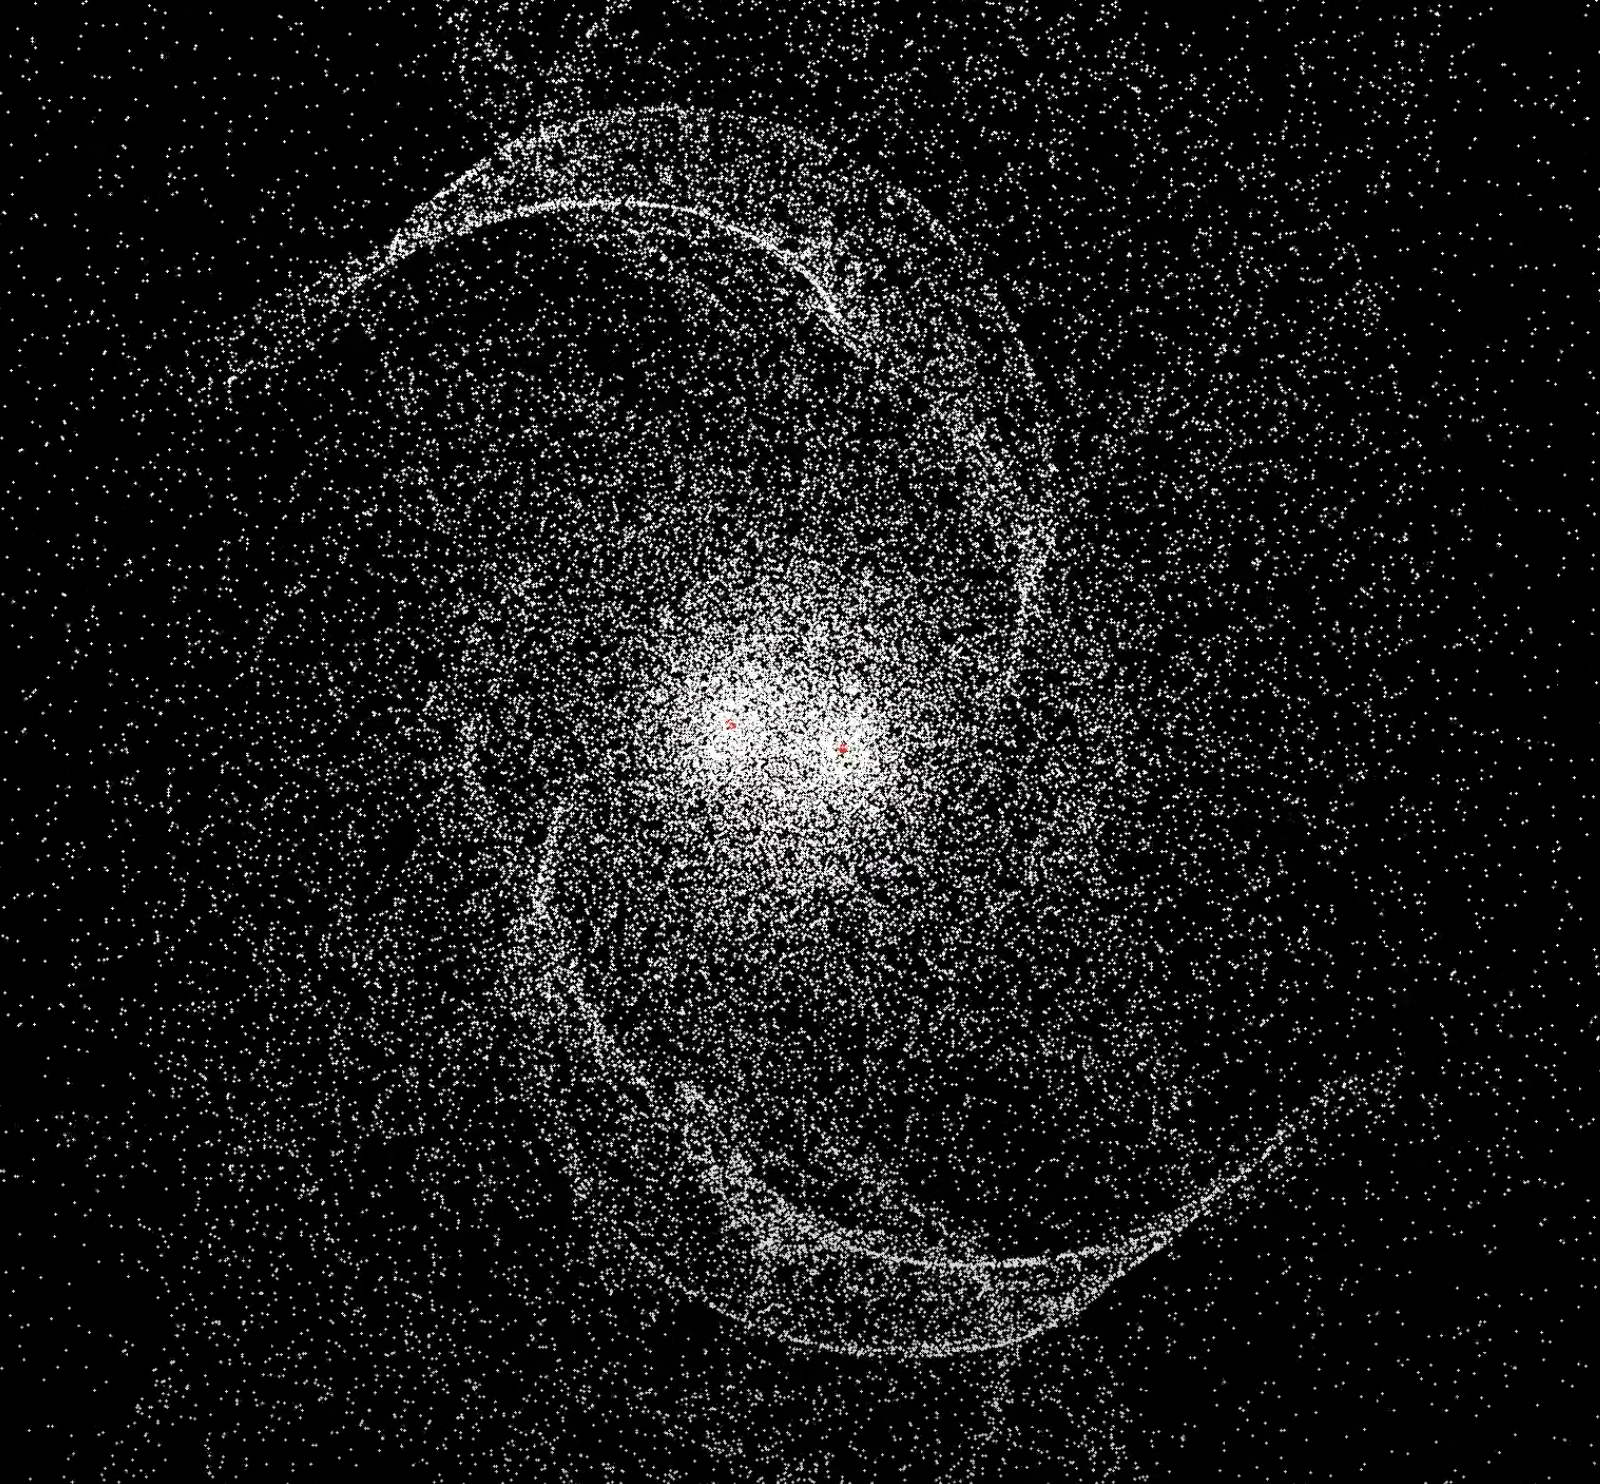

In [18]:
# Display the generated PNG image
from IPython.display import Image, display
display(Image('/content/galaxy_collision.png'))

In [22]:
%%writefile galaxy_collision.cu

#include <cuda_runtime.h>
#include <cmath>
#include <cstdio>
#include <cstdlib>
#include <iostream>
#include <vector>
#include <random>
#include <algorithm>

using namespace std;

constexpr float PI = 3.14159265358979323846f;

// ============================================================
// SIMULATION SETTINGS
// ============================================================

const int DISK_STARS  = 2100;
const int BULGE_STARS = 400;

const int STARS_PER_GALAXY =
    DISK_STARS + BULGE_STARS;

const int N =
    2 * STARS_PER_GALAXY;

const int WIDTH  = 1400;
const int HEIGHT = 1400;

const int TILE_SIZE = 256;

const float G = 1.0f;
const float EPSILON = 0.22f;

const float DT = 0.012f;

// Collision duration
const int STEPS = 430;

const float GALAXY_RADIUS = 38.0f;


// ============================================================
// PARTICLE
// ============================================================

struct Particle
{
    float x, y, z;
    float vx, vy, vz;

    float mass;
    float brightness;

    int galaxyID;
};


// ============================================================
// CUDA ERROR CHECK
// ============================================================

void checkCUDA(cudaError_t error, const char* message)
{
    if (error != cudaSuccess)
    {
        cerr << "\nCUDA ERROR: "
             << message
             << " -> "
             << cudaGetErrorString(error)
             << endl;

        exit(EXIT_FAILURE);
    }
}


// ============================================================
// CUDA N-BODY GRAVITY
// SHARED MEMORY TILING
// ============================================================

__global__
void calculateGravity(
    const float4* position,
    float4* acceleration,
    int n)
{
    __shared__ float4 tile[TILE_SIZE];

    int i =
        blockIdx.x * blockDim.x
        + threadIdx.x;

    if (i >= n)
        return;

    float4 pi = position[i];

    float ax = 0.0f;
    float ay = 0.0f;
    float az = 0.0f;


    for (
        int start = 0;
        start < n;
        start += TILE_SIZE
    )
    {
        int j =
            start + threadIdx.x;

        if (j < n)
            tile[threadIdx.x] =
                position[j];

        __syncthreads();


        int count =
            min(
                TILE_SIZE,
                n - start
            );


        for (int k = 0; k < count; k++)
        {
            float4 pj = tile[k];

            float dx =
                pj.x - pi.x;

            float dy =
                pj.y - pi.y;

            float dz =
                pj.z - pi.z;


            float r2 =
                dx * dx
                + dy * dy
                + dz * dz
                + EPSILON * EPSILON;


            float invR =
                rsqrtf(r2);

            float invR3 =
                invR * invR * invR;


            float factor =
                G
                * pj.w
                * invR3;


            ax += factor * dx;
            ay += factor * dy;
            az += factor * dz;
        }

        __syncthreads();
    }


    acceleration[i] =
        make_float4(
            ax,
            ay,
            az,
            0.0f
        );
}


// ============================================================
// LEAPFROG VELOCITY
// ============================================================

__global__
void halfVelocity(
    float4* velocity,
    const float4* acceleration,
    int n,
    float dt)
{
    int i =
        blockIdx.x * blockDim.x
        + threadIdx.x;

    if (i >= n)
        return;


    velocity[i].x +=
        0.5f * acceleration[i].x * dt;

    velocity[i].y +=
        0.5f * acceleration[i].y * dt;

    velocity[i].z +=
        0.5f * acceleration[i].z * dt;
}


// ============================================================
// POSITION UPDATE
// ============================================================

__global__
void updatePosition(
    float4* position,
    const float4* velocity,
    int n,
    float dt)
{
    int i =
        blockIdx.x * blockDim.x
        + threadIdx.x;

    if (i >= n)
        return;


    position[i].x +=
        velocity[i].x * dt;

    position[i].y +=
        velocity[i].y * dt;

    position[i].z +=
        velocity[i].z * dt;
}


// ============================================================
// CREATE GALAXY
// ============================================================

void createGalaxy(
    vector<Particle>& particles,
    mt19937& rng,

    float centerX,
    float centerY,

    float initialVx,
    float initialVy,

    float rotationAngle,

    int galaxyID)
{
    normal_distribution<float>
        gaussian(0.0f, 1.0f);

    uniform_real_distribution<float>
        uniform01(0.0f, 1.0f);


    // ========================================================
    // DISK
    // ========================================================

    for (int i = 0; i < DISK_STARS; i++)
    {
        float u =
            uniform01(rng);


        // Exponential disk
        float r =
            -8.0f
            * logf(
                max(
                    0.0001f,
                    1.0f - u
                )
            );


        r =
            min(
                r,
                GALAXY_RADIUS
            );


        // ----------------------------------------------------
        // Four spiral arms
        // ----------------------------------------------------

        int arm =
            i % 4;


        float armBase =
            2.0f
            * PI
            * arm
            / 4.0f;


        // logarithmic spiral
        float spiral =
            0.72f
            * logf(r + 1.0f);


        float angularNoise =
            gaussian(rng)
            * 0.115f;


        float theta =
            armBase
            + spiral
            + angularNoise;


        // ----------------------------------------------------
        // Thin galactic disk
        // ----------------------------------------------------

        float localZ =
            gaussian(rng)
            * (
                0.10f
                + 0.010f * r
            );


        float localX =
            r * cosf(theta);

        float localY =
            r * sinf(theta);


        // ----------------------------------------------------
        // Circular velocity
        // ----------------------------------------------------

        float orbitalVelocity =
            sqrtf(
                G * 32.0f
                / (r + 3.0f)
            );


        orbitalVelocity *=
            0.95f
            + 0.10f
            * uniform01(rng);


        float localVx =
            -orbitalVelocity
            * sinf(theta);

        float localVy =
            orbitalVelocity
            * cosf(theta);


        // ----------------------------------------------------
        // Rotate galaxy
        // ----------------------------------------------------

        float c =
            cosf(rotationAngle);

        float s =
            sinf(rotationAngle);


        float x =
            c * localX
            - s * localY;

        float y =
            s * localX
            + c * localY;


        float vx =
            c * localVx
            - s * localVy;

        float vy =
            s * localVx
            + c * localVy;


        Particle p;


        p.x =
            centerX + x;

        p.y =
            centerY + y;

        p.z =
            localZ;


        p.vx =
            initialVx + vx;

        p.vy =
            initialVy + vy;

        p.vz =
            gaussian(rng)
            * 0.018f;


        p.mass =
            0.0028f;


        // Central stars brighter
        p.brightness =
            0.40f
            + 0.60f
            * expf(
                -r * r / 350.0f
            );


        // Small brightness variation
        p.brightness +=
            gaussian(rng) * 0.07f;


        p.brightness =
            max(
                0.12f,
                min(
                    1.0f,
                    p.brightness
                )
            );


        p.galaxyID =
            galaxyID;


        particles.push_back(p);
    }


    // ========================================================
    // CENTRAL BULGE
    // ========================================================

    for (int i = 0; i < BULGE_STARS; i++)
    {
        float r =
            fabs(
                gaussian(rng)
                * 3.0f
            );


        float theta =
            uniform01(rng)
            * 2.0f
            * PI;


        float phi =
            acosf(
                2.0f
                * uniform01(rng)
                - 1.0f
            );


        float x =
            r
            * sinf(phi)
            * cosf(theta);


        float y =
            r
            * sinf(phi)
            * sinf(theta);


        float z =
            r * cosf(phi);


        float v =
            sqrtf(
                G * 38.0f
                / (r + 2.0f)
            );


        Particle p;


        p.x =
            centerX + x;

        p.y =
            centerY + y;

        p.z =
            z;


        p.vx =
            initialVx
            - v * sinf(theta);

        p.vy =
            initialVy
            + v * cosf(theta);

        p.vz =
            gaussian(rng)
            * 0.035f;


        p.mass =
            0.007f;


        p.brightness =
            1.0f;


        p.galaxyID =
            galaxyID;


        particles.push_back(p);
    }
}


// ============================================================
// COLLISION INITIAL CONDITIONS
// ============================================================

vector<Particle> createCollision()
{
    vector<Particle> particles;

    particles.reserve(N);


    mt19937 rng(2026);


    // ========================================================
    // GALAXY A
    // ========================================================
    //
    // Starts left/top and moves toward the center.
    //
    createGalaxy(
        particles,

        rng,

        -31.0f,
         9.0f,

         0.43f,
        -0.06f,

         0.25f,

         0
    );


    // ========================================================
    // GALAXY B
    // ========================================================
    //
    // Starts right/bottom.
    //
    createGalaxy(
        particles,

        rng,

         31.0f,
        -9.0f,

        -0.43f,
         0.06f,

         PI + 0.55f,

         1
    );


    return particles;
}


// ============================================================
// FINAL IMAGE RENDERER
// ============================================================

void renderGalaxy(
    const vector<Particle>& particles,
    const string& filename)
{
    vector<float>
        image(
            WIDTH * HEIGHT,
            0.0f
        );


    // ========================================================
    // STAR PROJECTION
    // ========================================================

    for (const auto& p : particles)
    {
        const float scale =
            9.4f;


        int px =
            WIDTH / 2
            + static_cast<int>(
                p.x * scale
            );


        int py =
            HEIGHT / 2
            - static_cast<int>(
                p.y * scale
            );


        if (
            px < 0 ||
            px >= WIDTH ||
            py < 0 ||
            py >= HEIGHT
        )
            continue;


        // Depth slightly changes brightness
        float depth =
            expf(
                -0.025f
                * fabs(p.z)
            );


        float brightness =
            p.brightness
            * depth;


        // ====================================================
        // STAR GLOW
        // ====================================================

        for (int dx = -2; dx <= 2; dx++)
        {
            for (int dy = -2; dy <= 2; dy++)
            {
                int xx =
                    px + dx;

                int yy =
                    py + dy;


                if (
                    xx < 0 ||
                    xx >= WIDTH ||
                    yy < 0 ||
                    yy >= HEIGHT
                )
                    continue;


                float distanceSquared =
                    float(
                        dx * dx
                        + dy * dy
                    );


                float glow =
                    expf(
                        -distanceSquared
                        / 1.4f
                    );


                int index =
                    yy * WIDTH
                    + xx;


                image[index] +=
                    brightness
                    * glow;
            }
        }
    }


    // ========================================================
    // MAXIMUM BRIGHTNESS
    // ========================================================

    float maximum =
        0.0f;


    for (float value : image)
    {
        maximum =
            max(
                maximum,
                value
            );
    }


    // ========================================================
    // WRITE PPM
    // ========================================================

    FILE* file =
        fopen(
            filename.c_str(),
            "wb"
        );


    if (!file)
    {
        cerr
            << "Could not create image."
            << endl;

        return;
    }


    fprintf(
        file,
        "P6\n%d %d\n255\n",
        WIDTH,
        HEIGHT
    );


    for (
        int i = 0;
        i < WIDTH * HEIGHT;
        i++
    )
    {
        float value =
            image[i]
            / (maximum + 0.0001f);


        // HDR compression
        value =
            1.0f
            - expf(
                -5.0f
                * value
            );


        // Increase contrast
        value =
            powf(
                value,
                0.58f
            );


        unsigned char pixel =
            static_cast<unsigned char>(
                min(
                    255.0f,
                    value * 255.0f
                )
            );


        // Pure white stars
        fwrite(
            &pixel,
            1,
            1,
            file
        );

        fwrite(
            &pixel,
            1,
            1,
            file
        );

        fwrite(
            &pixel,
            1,
            1,
            file
        );
    }


    fclose(file);
}


// ============================================================
// MAIN
// ============================================================

int main()
{
    cout << "\n";
    cout << "============================================\n";
    cout << "       CUDA GALAXY COLLISION\n";
    cout << "============================================\n";

    cout
        << "Particles: "
        << N
        << "\n";

    cout
        << "CUDA N-body: ENABLED\n";

    cout
        << "Shared memory tiling: ENABLED\n";

    cout
        << "Leapfrog integration: ENABLED\n";

    cout
        << "Spiral galaxies: 2\n";


    // ========================================================
    // CREATE GALAXIES
    // ========================================================

    vector<Particle>
        particles =
            createCollision();


    cout
        << "Two galaxies generated.\n";


    // ========================================================
    // HOST ARRAYS
    // ========================================================

    vector<float4>
        h_position(N);

    vector<float4>
        h_velocity(N);

    vector<float4>
        h_acceleration(N);


    for (int i = 0; i < N; i++)
    {
        h_position[i] =
            make_float4(
                particles[i].x,
                particles[i].y,
                particles[i].z,
                particles[i].mass
            );


        h_velocity[i] =
            make_float4(
                particles[i].vx,
                particles[i].vy,
                particles[i].vz,
                0.0f
            );
    }


    // ========================================================
    // GPU MEMORY
    // ========================================================

    float4* d_position;
    float4* d_velocity;
    float4* d_acceleration;


    size_t bytes =
        N * sizeof(float4);


    checkCUDA(
        cudaMalloc(
            &d_position,
            bytes
        ),
        "position allocation"
    );


    checkCUDA(
        cudaMalloc(
            &d_velocity,
            bytes
        ),
        "velocity allocation"
    );


    checkCUDA(
        cudaMalloc(
            &d_acceleration,
            bytes
        ),
        "acceleration allocation"
    );


    // ========================================================
    // COPY HOST → GPU
    // ========================================================

    checkCUDA(
        cudaMemcpy(
            d_position,
            h_position.data(),
            bytes,
            cudaMemcpyHostToDevice
        ),
        "position copy"
    );


    checkCUDA(
        cudaMemcpy(
            d_velocity,
            h_velocity.data(),
            bytes,
            cudaMemcpyHostToDevice
        ),
        "velocity copy"
    );


    // ========================================================
    // CUDA CONFIG
    // ========================================================

    int blockSize =
        TILE_SIZE;


    int gridSize =
        (
            N
            + blockSize
            - 1
        )
        / blockSize;


    cout
        << "CUDA blocks: "
        << gridSize
        << "\n";


    // ========================================================
    // INITIAL FORCE
    // ========================================================

    calculateGravity<<<
        gridSize,
        blockSize
    >>>(
        d_position,
        d_acceleration,
        N
    );


    checkCUDA(
        cudaDeviceSynchronize(),
        "initial gravity"
    );


    // ========================================================
    // SIMULATION
    // ========================================================

    cout
        << "\nStarting galaxy collision...\n";


    for (
        int step = 0;
        step < STEPS;
        step++
    )
    {
        // --------------------------------------------
        // Leapfrog 1
        // --------------------------------------------

        halfVelocity<<<
            gridSize,
            blockSize
        >>>(
            d_velocity,
            d_acceleration,
            N,
            DT
        );


        // --------------------------------------------
        // Position
        // --------------------------------------------

        updatePosition<<<
            gridSize,
            blockSize
        >>>(
            d_position,
            d_velocity,
            N,
            DT
        );


        // --------------------------------------------
        // New gravity
        // --------------------------------------------

        calculateGravity<<<
            gridSize,
            blockSize
        >>>(
            d_position,
            d_acceleration,
            N
        );


        // --------------------------------------------
        // Leapfrog 2
        // --------------------------------------------

        halfVelocity<<<
            gridSize,
            blockSize
        >>>(
            d_velocity,
            d_acceleration,
            N,
            DT
        );


        if (step % 25 == 0)
        {
            cout
                << "Step "
                << step
                << " / "
                << STEPS
                << "\n";
        }
    }


    checkCUDA(
        cudaDeviceSynchronize(),
        "simulation synchronization"
    );


    // ========================================================
    // GPU → HOST
    // ========================================================

    checkCUDA(
        cudaMemcpy(
            h_position.data(),
            d_position,
            bytes,
            cudaMemcpyDeviceToHost
        ),
        "final position copy"
    );


    // ========================================================
    // UPDATE PARTICLES
    // ========================================================

    for (int i = 0; i < N; i++)
    {
        particles[i].x =
            h_position[i].x;

        particles[i].y =
            h_position[i].y;

        particles[i].z =
            h_position[i].z;
    }


    // ========================================================
    // RENDER
    // ========================================================

    cout
        << "\nRendering final galaxy collision...\n";


    renderGalaxy(
        particles,
        "galaxy_collision_final.ppm"
    );


    // ========================================================
    // CLEANUP
    // ========================================================

    cudaFree(d_position);
    cudaFree(d_velocity);
    cudaFree(d_acceleration);


    cout
        << "\n============================================\n";

    cout
        << "GALAXY COLLISION COMPLETE\n";

    cout
        << "Output: galaxy_collision_final.ppm\n";

    cout
        << "============================================\n";


    return 0;
}

Overwriting galaxy_collision.cu


--- Starting full galaxy collision simulation workflow ---

--- Checking CUDA Installation ---
nvcc not found or not working. Proceeding with CUDA toolkit installation.
/bin/bash: line 1: apt-get: command not found
/bin/bash: line 1: apt-get: command not found
env: PATH={cuda_path}/bin:$PATH
env: LD_LIBRARY_PATH={cuda_path}/lib64:$LD_LIBRARY_PATH

--- Verifying nvcc version ---
/bin/bash: line 1: nvcc: command not found
/content/galaxy_collision

--- Compiling CUDA code ---
/bin/bash: line 1: nvcc: command not found

--- Running galaxy collision simulation ---
/bin/bash: line 1: ./galaxy_collision: No such file or directory

--- Checking ImageMagick Installation ---
ImageMagick not found. Installing now...
/bin/bash: line 1: apt-get: command not found
/bin/bash: line 1: apt-get: command not found

--- Converting PPM to PNG ---
/bin/bash: line 1: convert: command not found

--- Displaying final image ---


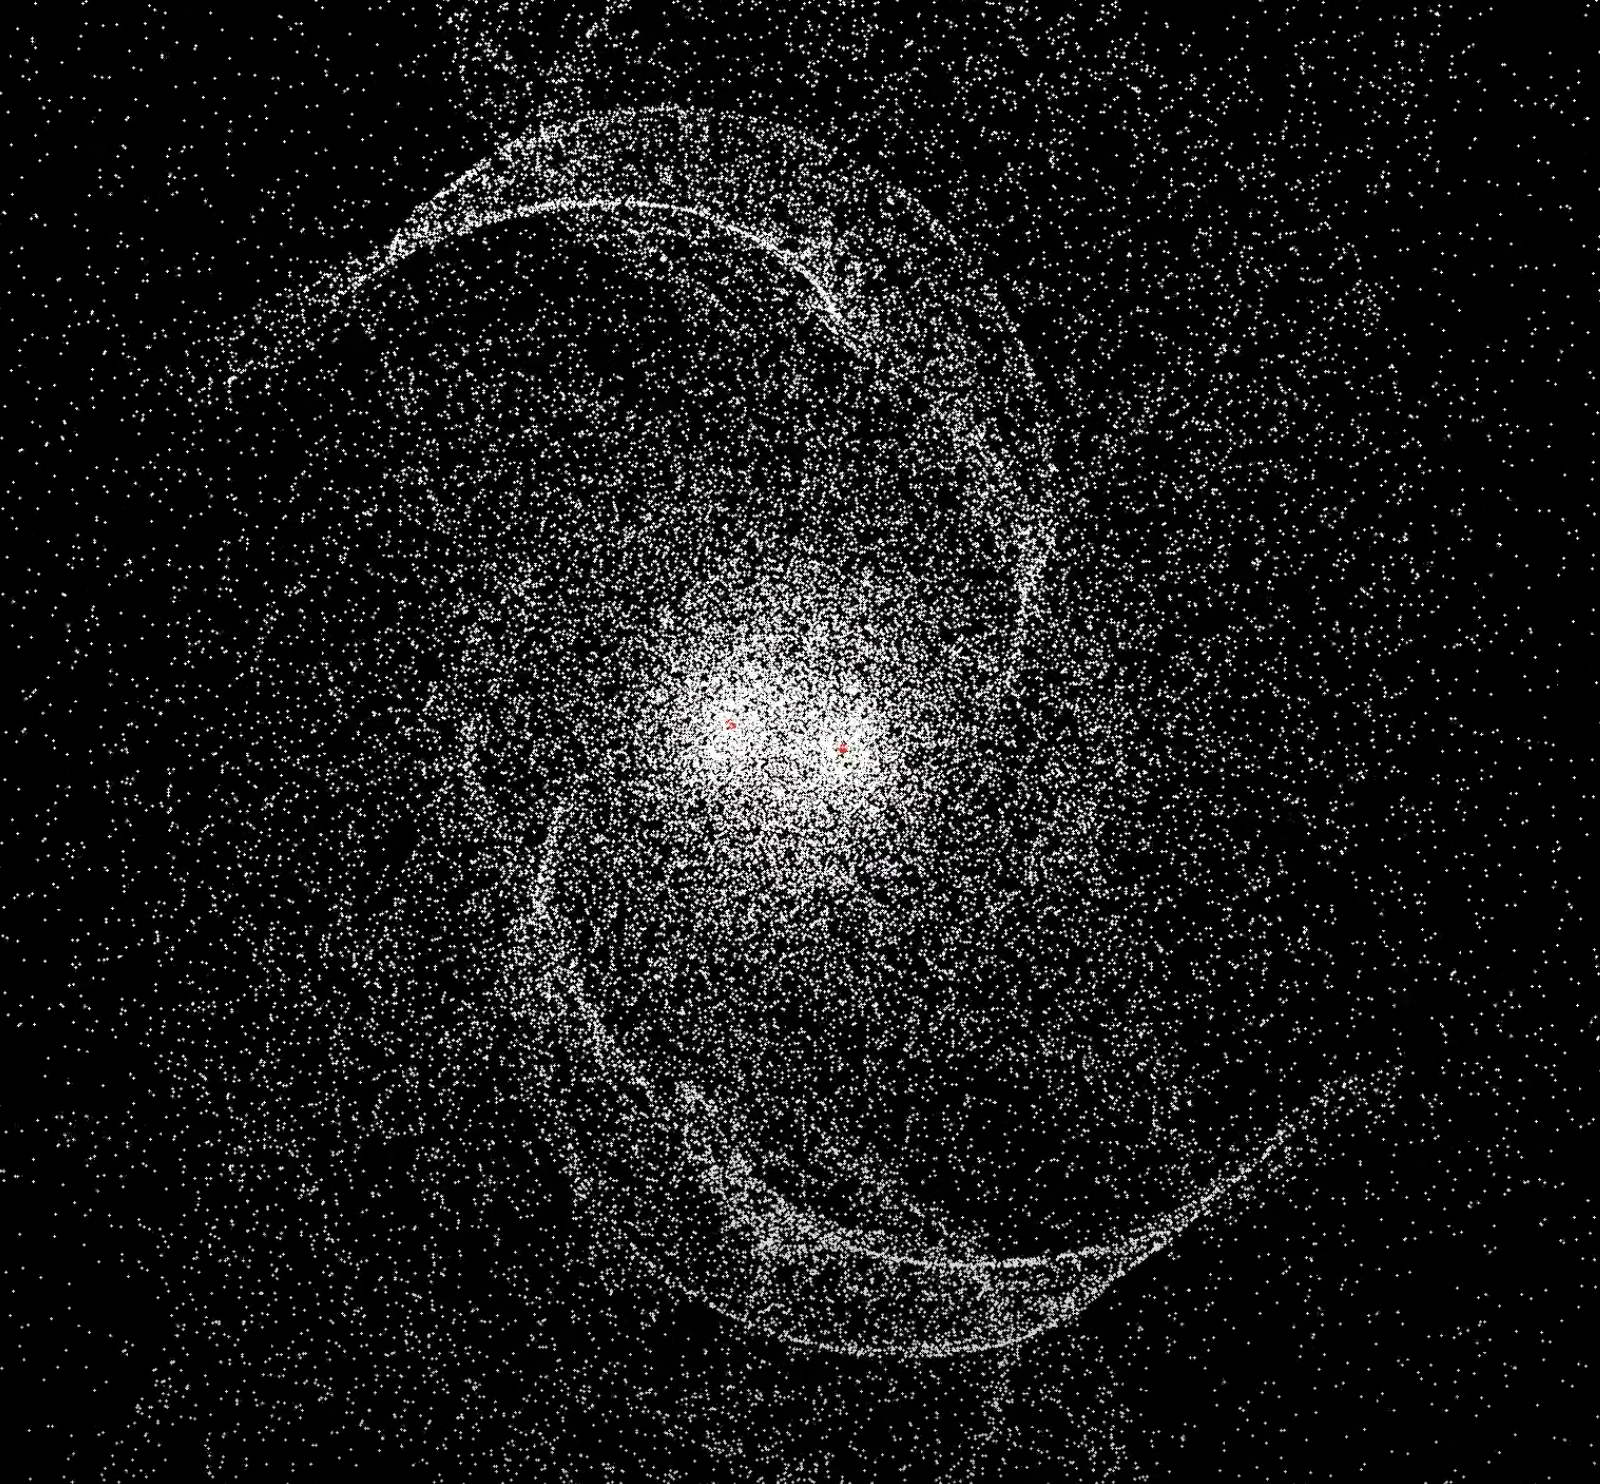


--- Workflow complete ---


In [23]:
import os
import subprocess
from IPython.display import Image, display

print("--- Starting full galaxy collision simulation workflow ---")

# 1. Ensure CUDA Toolkit is installed and environment variables are set
print("\n--- Checking CUDA Installation ---")
try:
    # Use the current working directory to check for nvcc
    subprocess.run(['nvcc', '--version'], check=True, capture_output=True, cwd='/content/galaxy_collision')
    print("nvcc is already installed and in PATH.")
except (FileNotFoundError, subprocess.CalledProcessError):
    print("nvcc not found or not working. Proceeding with CUDA toolkit installation.")
    !apt-get update -qq > /dev/null
    # Use cuda-toolkit for general installation, which resolves to the latest compatible version
    !apt-get install -y cuda-toolkit > /dev/null

# Set environment variables for CUDA to the default Colab path
# This is crucial for nvcc to be found after installation
# Find the actual CUDA path, which might be versioned (e.g., /usr/local/cuda-12.2)
cuda_path = '/usr/local/cuda'
if not os.path.exists(cuda_path):
    # Try to find a versioned path
    cuda_dirs = [d for d in os.listdir('/usr/local') if d.startswith('cuda-')]
    if cuda_dirs:
        cuda_path = os.path.join('/usr/local', max(cuda_dirs)) # Pick the latest version
        print(f"Detected CUDA installation at: {cuda_path}")
    else:
        print("Warning: Could not find CUDA installation directory.")

%env PATH={cuda_path}/bin:$PATH
%env LD_LIBRARY_PATH={cuda_path}/lib64:$LD_LIBRARY_PATH

# Verify nvcc installation after setting path
print("\n--- Verifying nvcc version ---")
!nvcc --version

# Change to the working directory
%cd /content/galaxy_collision

# 2. Compile the CUDA code
print("\n--- Compiling CUDA code ---")
!nvcc -O3 -std=c++17 galaxy_collision.cu -o galaxy_collision

# 3. Run the compiled executable
print("\n--- Running galaxy collision simulation ---")
!./galaxy_collision

# 4. Install ImageMagick to convert PPM to PNG
print("\n--- Checking ImageMagick Installation ---")
try:
    subprocess.run(['convert', '-version'], check=True, capture_output=True)
    print("ImageMagick is already installed.")
except (FileNotFoundError, subprocess.CalledProcessError):
    print("ImageMagick not found. Installing now...")
    !apt-get update -qq > /dev/null
    !apt-get install -y imagemagick > /dev/null

# 5. Convert the generated PPM image to PNG
print("\n--- Converting PPM to PNG ---")
# Ensure output filename is consistent
!convert galaxy_collision_final.ppm /content/galaxy_collision.png

# 6. Display the generated PNG image
print("\n--- Displaying final image ---")
display(Image('/content/galaxy_collision.png'))

print("\n--- Workflow complete ---")